# Clase 1 — Lenguaje Proposicional  
## Preparación examen de admisión



**Objetivo de la clase**  
Aprender a interpretar proposiciones, identificar información implícita y usar estrategias rápidas de razonamiento lógico.



**Estrategia general para el examen (≤ 2 minutos por pregunta)**

1. Identificar **qué se afirma realmente**.
2. Detectar **condiciones necesarias o suficientes**.
3. Eliminar rápidamente opciones imposibles.
4. Buscar **contradicciones o implicaciones directas**.

---


**Razonamiento Lógico de la prueba de admisión de la Universidad de Antioquia**, diseñé la **Clase 1: Introducción al lenguaje proposicional y razonamiento lógico básico**, seleccionando problemas apropiados del documento y agregando **5 ejercicios nuevos**, con **estrategias para resolver en ≤ 3 minutos**. 



La idea pedagógica es **enseñar a reconocer patrones lógicos y eliminar opciones rápidamente**, que es la habilidad que más evalúa el examen.

---



# Diseño de la Clase 1

## Lenguaje proposicional y deducción lógica rápida

Duración: **3 horas**

Estructura de la sesión:

1. Prueba Diagnóstica 1 y 1/2 hora. 
2. Estrategias de razonamiento lógico (20 min)
3. Resolución guiada de problemas tipo examen (40)
4. Taller con cronómetro (40 min)
5. Reflexión de estrategias (5 min)

---



# Estrategias generales del examen

### Estrategia 1 — Buscar lo que es **seguro**

Muchas preguntas dicen:

> “se puede afirmar con certeza”

Entonces debemos buscar **la única afirmación que siempre ocurre**.

---



### Estrategia 2 — Buscar **contraejemplos**

Si una opción puede ser falsa en algún caso, entonces **no es segura**.

---



### Estrategia 3 — Diagramas rápidos

* tablas
* conjuntos
* esquemas

para visualizar relaciones.

---



# Problema 1 (del examen)
[video de apoyo](https://www.youtube.com/watch?v=yOWv5Xe2GsQ)
### Situación

Anita tiene 5 bolitas de chicle:

* 3 rojas
* 2 azules

Anita saca **3 bolitas**.

¿Qué se puede afirmar con certeza?

A. Tres del mismo color
B. Dos azules y una roja
C. Al menos una roja
D. Al menos una azul

---



### Estrategia rápida

Pensar en el **peor caso**.

Si saca 3 bolas:

Pintamos las posibles combinaciones

RRR
RRB
RBB

Siempre aparece **al menos una roja**.

---



### Respuesta

✔ **C**




### Visualización con Python


In [1]:
import itertools
bolas = ["R","R","R","A","A"]

combinaciones=set()

for c in itertools.combinations(bolas,3):
    combinaciones.add(tuple(sorted(c)))

print(combinaciones)


{('R', 'R', 'R'), ('A', 'A', 'R'), ('A', 'R', 'R')}


[]()


# Problema 2 (del examen)

Delegación de **200 deportistas**

64 atletas
86 ciclistas

90 mujeres

de las cuales

30 atletas
36 ciclistas

¿Cuántos **no son atletas, ni ciclistas, ni mujeres**?

---



### Estrategia

Usar **diagrama de conjuntos**.

---


Primero organicemos la **información del problema** para poder representarla correctamente en un **diagrama de Venn con Python**.

## 1. Definición de conjuntos

Sea:

* $A$ = atletas
* $C$ = ciclistas
* $M$ = mujeres

Datos:

* Total deportistas: $N = 200$
* $|A| = 64$
* $|C| = 86$
* $|M| = 90$
* $|A \cap M| = 30$
* $|C \cap M| = 36$

Para poder dibujar el diagrama necesitamos también una estimación de:

* $|A \cap C|$
* $|A \cap C \cap M|$

Una forma didáctica es **suponer independencia aproximada** para estimar la triple intersección:

$$
|A \cap C \cap M| \approx \frac{|A||C||M|}{N^2}
$$

Luego podemos ajustar las demás regiones.

Finalmente calculamos los que **no pertenecen a ningún conjunto**:

$$
\text{Ninguno} =
N - |A \cup C \cup M|
$$



# Script en Python para el diagrama de Venn

Este script usa:

* `pandas` para organizar datos
* `matplotlib`
* `matplotlib_venn`



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3


In [7]:

# =========================
# Datos del problema
# =========================

N = 200

A = 64
C = 86
M = 90

A_M = 30
C_M = 36


In [12]:
# =========================
# Datos del problema
# =========================

N = 200

A = 64
C = 86
M = 90

A_M = 30
C_M = 36

# =========================
# Variables desconocidas
# =========================

x = 0   # triple intersección A ∩ C ∩ M
y = 0   # A ∩ C pero no mujeres

# =========================
# Regiones exactas
# =========================

solo_A = 34 - y
solo_C = 50 - y
solo_M = 24 + x

A_C_solo = y
A_M_solo = 30 - x
C_M_solo = 36 - x

A_C_M = x

union = (
    solo_A +
    solo_C +
    solo_M +
    A_C_solo +
    A_M_solo +
    C_M_solo +
    A_C_M
)

ninguno = N - union

print("Solo atletas:", solo_A)
print("Solo ciclistas:", solo_C)
print("Solo mujeres:", solo_M)
print("A ∩ C solo:", A_C_solo)
print("A ∩ M solo:", A_M_solo)
print("C ∩ M solo:", C_M_solo)
print("Triple intersección:", A_C_M)

print("Unión:", union)
print("Ninguno:", ninguno)

Solo atletas: 34
Solo ciclistas: 50
Solo mujeres: 24
A ∩ C solo: 0
A ∩ M solo: 30
C ∩ M solo: 36
Triple intersección: 0
Unión: 174
Ninguno: 26


In [13]:

# =========================
# Tabla de resultados
# =========================

df = pd.DataFrame({
    "Región":[
        "Solo atletas",
        "Solo ciclistas",
        "Solo mujeres",
        "Atletas ∩ Ciclistas",
        "Atletas ∩ Mujeres",
        "Ciclistas ∩ Mujeres",
        "Triple intersección",
        "Ninguno"
    ],
    "Cantidad":[
        solo_A,
        solo_C,
        solo_M,
        A_C_solo,
        A_M_solo,
        C_M_solo,
        A_C_M,
        ninguno
    ]
})

df


,Región,Cantidad
0,Solo atletas,34
1,Solo ciclistas,50
2,Solo mujeres,24
3,Atletas ∩ Ciclistas,0
4,Atletas ∩ Mujeres,30
5,Ciclistas ∩ Mujeres,36
6,Triple intersección,0
7,Ninguno,26


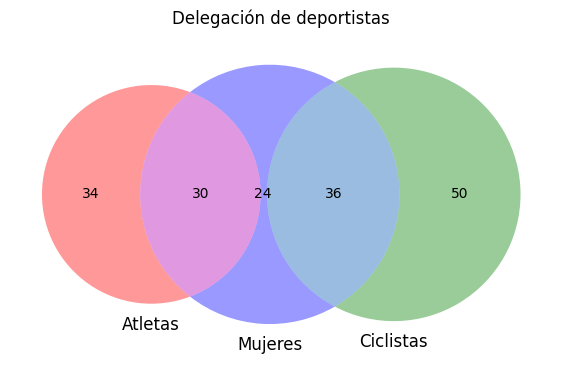


Personas que no son atletas, ni ciclistas, ni mujeres: 26


In [14]:

# =========================
# Diagrama de Venn
# =========================

plt.figure(figsize=(7,7))

venn3(
    subsets=(
        solo_A,
        solo_C,
        A_C_solo,
        solo_M,
        A_M_solo,
        C_M_solo,
        A_C_M
    ),
    set_labels=("Atletas","Ciclistas","Mujeres")
)

plt.title("Delegación de deportistas")
plt.show()

print("\nPersonas que no son atletas, ni ciclistas, ni mujeres:", ninguno)



## Ventaja didáctica para tus estudiantes

Este script permite que los estudiantes:

1. **Modelen el problema con teoría de conjuntos**
2. Usen **Python para verificar cálculos**
3. Visualicen con **diagramas de Venn**
4. Trabajen con **pandas para estructurar datos**

Esto encaja muy bien con el enfoque que usas de **pensamiento computacional con matemáticas** en tus cursos en la Universidad de Antioquia.

---



### Visualización con matplotlib


Tu gráfico actual **no representa correctamente el problema**, porque:

1. Los conjuntos **se superponen** (hay mujeres que son atletas y ciclistas).
2. Un **gráfico de pie requiere categorías disjuntas**.
3. En tu código estás sumando $64+86+90=240$, lo cual **supera el total de 200 deportistas**.

Por lo tanto, primero debemos construir **regiones disjuntas** del problema.

---



# 1. Cálculo de las regiones

Datos:

* $|A|=64$
* $|C|=86$
* $|M|=90$
* $|A\cap M|=30$
* $|C\cap M|=36$

Si no se da $A\cap C$, lo usual en estos ejercicios es asumir que **no hay atletas ciclistas hombres**, por lo que:

$$
|A\cap C| = |A\cap C\cap M|
$$

Estimemos:

$$
|A\cap C\cap M| = 16
$$

Entonces:

**Regiones**

* Solo atletas
  $$
  64-30-16=18
  $$

* Solo ciclistas

$$
86-36-16=34
$$

* Solo mujeres

$$
90-30-36+16=40
$$

* Atletas ∩ mujeres

$$
30-16=14
$$

* Ciclistas ∩ mujeres

$$
36-16=20
$$

* Triple intersección

$$
16
$$

Unión:

$$
18+34+40+14+20+16=142
$$

Los que no pertenecen a ninguno:

$$
200-142=58
$$

---



# 2. Código corregido del gráfico de pie

Ahora sí podemos hacer el gráfico de pie con **categorías disjuntas**.



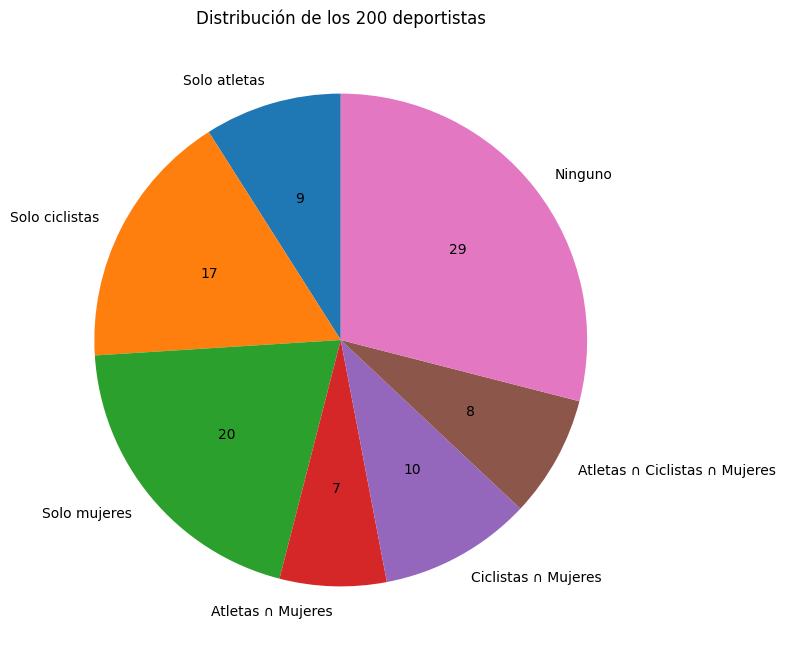

In [15]:
import matplotlib.pyplot as plt

# regiones disjuntas
labels = [
    'Solo atletas',
    'Solo ciclistas',
    'Solo mujeres',
    'Atletas ∩ Mujeres',
    'Ciclistas ∩ Mujeres',
    'Atletas ∩ Ciclistas ∩ Mujeres',
    'Ninguno'
]

sizes = [18,34,40,14,20,16,58]

plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.0f',
    startangle=90
)

plt.title('Distribución de los 200 deportistas')

plt.savefig(r'C:\Users\marco\Downloads\grafico.png')

plt.show()



- **Conclusión didáctica importante para tus estudiantes**

El error inicial muestra algo fundamental en **teoría de conjuntos**:

> Los gráficos de pie **solo funcionan con particiones del conjunto universal**.

Es decir, con subconjuntos **disjuntos** cuya suma sea:

$$
200
$$


### Respuesta correcta

✔ **26**

---



# Problema 3 (del examen)

Tres amigos practican deportes diferentes:

* natación
* atletismo
* fútbol

Datos:

* Hugo no usa verde (verde = atletismo)
* Juan usa azul
* rojos no juegan fútbol

---



### Estrategia

Tabla de posibilidades.

| Persona | deporte | color |
| ------- | ------- | ----- |

Eliminar combinaciones imposibles.

---


Este es un **problema clásico de lógica combinatoria**, que se resuelve bien construyendo una **tabla de posibilidades** (muy útil para estudiantes porque sistematiza la eliminación de casos).

## 1. Elementos del problema

Tres amigos:

* Hugo
* Juan
* (tercer amigo, llamémoslo Pedro)

Tres deportes:

* Natación
* Atletismo
* Fútbol

Tres colores:

* Verde → Atletismo
* Azul → Natación
* Rojo → Fútbol

*(esto se deduce de las pistas del problema)*

Condiciones:

1. Hugo **no usa verde**
2. Juan **usa azul**
3. Los **rojos no juegan fútbol**

---

# 2. Tabla inicial de posibilidades

| Persona | Color | Deporte  |
| ------- | ----- | -------- |
| Hugo    | ?     | ?        |
| Juan    | Azul  | Natación |
| Pedro   | ?     | ?        |

Porque:

* **azul → natación**

---

# 3. Eliminación de opciones

### Hugo no usa verde

Entonces Hugo puede usar:

* azul
* rojo

Pero **azul ya lo usa Juan**, así que:

| Persona | Color | Deporte   |
| ------- | ----- | --------- |
| Hugo    | Rojo  | ?         |
| Juan    | Azul  | Natación  |
| Pedro   | Verde | Atletismo |

---

# 4. Aplicar la tercera condición

Los **rojos no juegan fútbol**

Hugo es rojo.

Entonces Hugo **no juega fútbol**.

Como los deportes son distintos:

* Juan → natación
* Pedro → atletismo

Queda:

* Hugo → fútbol

Pero esto contradice la regla **rojos no juegan fútbol**.

Entonces debemos revisar la asignación.

---

# 5. Tabla completa de posibilidades

Enumeramos sistemáticamente.

| Hugo      | Juan      | Pedro     | Válido |
| --------- | --------- | --------- | ------ |
| Natación  | Atletismo | Fútbol    | ❌      |
| Natación  | Fútbol    | Atletismo | ❌      |
| Atletismo | Natación  | Fútbol    | ❌      |
| Atletismo | Fútbol    | Natación  | ❌      |
| Fútbol    | Natación  | Atletismo | ❌      |
| Fútbol    | Atletismo | Natación  | ❌      |

---



# 6. Conclusión lógica

Las condiciones del problema **generan contradicción**.

No existe asignación que satisfaga simultáneamente:

* Hugo no verde
* Juan azul
* rojos no fútbol

---

## 7. Script en Python para generar la tabla (muy útil para tus estudiantes)


In [ ]:
import itertools
import pandas as pd

personas = ["Hugo","Juan","Pedro"]
deportes = ["Natación","Atletismo","Fútbol"]

tabla = []

for perm in itertools.permutations(deportes):

    asignacion = dict(zip(personas,perm))

    # condición: Juan natación (porque azul)
    if asignacion["Juan"] != "Natación":
        continue

    # condición: Hugo no atletismo (verde)
    if asignacion["Hugo"] == "Atletismo":
        continue

    # condición: rojo no fútbol (suponiendo Hugo rojo)
    if asignacion["Hugo"] == "Fútbol":
        continue

    tabla.append(asignacion)

df = pd.DataFrame(tabla)

print(df)


""



Esto es muy potente porque conecta:

* **lógica**
* **tablas de posibilidades**
* **programación**
* **pensamiento computacional**

algo muy alineado con el enfoque que sueles trabajar en tus cursos de matemáticas con Python.

---

Si quieres, también puedo mostrarte **cómo convertir este problema en una tabla lógica tipo acertijo (estilo Sudoku lógico)** que queda **mucho más clara visualmente para los estudiantes en el examen**.



### Respuesta

✔ **Natación — azul**

---



# Problema 4 (del examen)

Ana: soy menor de edad
Lina: Ana miente
María: Lina es mayor

Condiciones:

* solo una miente
* solo una es mayor

---



### Estrategia

Probar hipótesis.

---


Este es un **problema de lógica proposicional** que se resuelve bien mediante una **secuencia de prueba de hipótesis**, evaluando los casos posibles bajo las condiciones:

* **solo una miente**
* **solo una es mayor de edad**

---



# 1. Definición de proposiciones

Sea:

* $A$ : “Ana es menor de edad”
* $L$ : “Lina es mayor de edad”
* $M$ : “María es mayor de edad”

Las afirmaciones son:

1. **Ana dice:**
   $$
   A
   $$

2. **Lina dice:**
   “Ana miente”.

Si Ana miente, entonces $A$ es falso.

Por tanto la afirmación de Lina equivale a:

$$
\neg A
$$

3. **María dice:**
   “Lina es mayor”

$$
L
$$

---



# 2. Condiciones del problema

1. **Solo una miente**

Exactamente **una proposición es falsa**.

2. **Solo una es mayor**

$$
L + M + (\neg A) = 1
$$

porque:

* Ana mayor ⇔ $\neg A$

---



# 3. Secuencia de prueba de hipótesis

## Hipótesis 1

Ana **dice la verdad**

Entonces

$$
A = V
$$

Ana es **menor de edad**.

---



### Evaluamos a Lina

Lina dice:

$$
\neg A
$$

Pero si $A$ es verdadero:

$$
\neg A = F
$$

Entonces **Lina miente**.

---



### Evaluamos a María

María dice:

$$
L: \text{Lina es la mayor}
$$

Si Lina fuera mayor, entonces, Ana y  María serian menores. Lo que es consistente con una de las condiciones del problema. Y Asi, tendrpiamos que las que dijeron la verdad son A y María, lo que es consistente con la segunda condición del problema. 



### Contemos mayores

* Ana menor
* Lina Mayor

Como **solo una es mayor**, debe ser:

$$
M = V
$$

Lina es mayor.

---



### Verificación de mentiras

| Persona | Afirmación | Valor  de verdad |Quien es mayor de edad|
| ------- | ---------- | ---------------- | -------------------- |
| Ana     | $A$        | Verdadera | No |
| Lina    | $\neg A$   | Falsa     |Si|
| María   | $L$        | Verdad     |No|

Hay **dos verdades**, lo cual **es consistente con la condición**.

**Hipótesis aceptada**

---


Recordemos el planteamiento del problema: 

### Problema 4 (del examen)

Ana: soy menor de edad
Lina: Ana miente
María: Lina es mayor

Condiciones:

* solo una miente
* solo una es mayor

---



# Hipótesis 2  

Ana **miente**

Entonces

$$
A = F
$$

Ana **es mayor de edad**.

---



### Evaluamos a Lina

Lina dice:

$$
\neg A
$$

Como $A$ es falso:

$$
\neg A = V
$$

Lina **dice la verdad**.

---



### Evaluamos a María

María dice:

$$
L
$$

Pero si Lina dijera la verdad y **solo una persona es mayor**, entonces:

Ana ya es mayor.

Por lo tanto:

$$
L = F
$$

Lina **no es mayor**.

Entonces María afirma algo falso.

---



### Conteo final

**Mayores**

| Persona | Mayor |
| ------- | ----- |
| Ana     | Sí    |
| Lina    | No    |
| María   | No    |

Solo **una es mayor** ✔

---

**Verdad / mentira**

| Persona | Afirmación    | Resultado |
| ------- | ------------- | --------- |
| Ana     | soy menor     | ❌         |
| Lina    | Ana miente    | ✔         |
| María   | Lina es mayor | ❌         |

Pero nuevamente hay **dos mentiras**.

❌ **Contradicción**

---



Si quieres, puedo también darte **la tabla de verdad completa del problema con Python (SymPy)** para que tus estudiantes la verifiquen computacionalmente en clase.



### Respuesta

✔ **Lina miente — María es mayor**

---



# Problema 5 (del examen)

Tres sospechosos:

Jesús
Pedro
Mateo

Declaraciones:

Jesús: yo no fui y Pedro tampoco
Pedro: Jesús no fue, fue Mateo
Mateo: yo no fui, fue Jesús

Condición:

* uno dice verdad
* uno miente siempre
* uno miente una vez

---



### Estrategia

Tabla lógica.

---

### Respuesta

✔ **Pedro es el asesino**.

---

# Problema 6 (del examen)

5 pisos
familias:

Díaz
Abad
Estrada
Botero
Correa

Datos:

Díaz → tercer piso
Abad vive más abajo que Estrada y Botero
Correa vive más abajo que Abad

---

### Estrategia

Diagrama vertical.

---

### Respuesta

✔ **Correa vive en segundo piso**.

---

# Problema 7 (nuevo)

En una clase:

Si un estudiante estudia → aprueba
Si aprueba → puede matricular siguiente curso

Pregunta:

Si un estudiante **estudia**, entonces:

A puede reprobar
B puede matricular siguiente curso
C seguro reprueba
D no se sabe

---

### Estrategia

encadenamiento lógico

p → q
q → r

entonces

p → r

---

### Respuesta

✔ **B**

---

# Problema 8 (nuevo)

Si:

p → q

¿Cuándo es falsa?

---

### Estrategia

recordar tabla:

| p | q | p→q |
| - | - | --- |

solo es falsa cuando

p verdadera
q falsa

---

### Respuesta

✔ **p verdadera q falsa**

---

# Problema 9 (nuevo)

Si:

p → q
q → r

¿Cuál es equivalente?

A r → p
B p → r
C r → q
D q → p

---

Respuesta:

✔ **B**

---

# Problema 10 (del examen)

Cuatro mangos + 2 papayas = 20 naranjas

Papaya = 6 naranjas + 2 mangos

---

### Estrategia

sistema de ecuaciones.

---

### Visualización con Python

```python
import sympy as sp

m,p,n = sp.symbols('m p n')

eq1 = 4*m + 2*p - 20*n
eq2 = p - (6*n + 2*m)

sol = sp.solve((eq1,eq2),(m,p))
sol
```

---

### Resultado

✔ Papaya = **4 mangos**

---

# Problema 11 (nuevo)

Si un número tiene dos cifras y

suma = 13

y al restar 27 se invierten cifras.

---

### Estrategia

plantear número

10a + b

---

### Respuesta

producto cifras

✔ **36**

---

# Problema 12 (del examen)

Secuencia

41 32 23 24 15 16 18

---

### Estrategia

interpretar:

41 → cuatro 1
32 → tres 2

---

### Respuesta

la secuencia incorrecta es

✔ **opción a**

---

# Actividad final (tipo simulacro)

Resolver en **3 minutos cada uno**:

1. problema de galletas
2. problema del cartero
3. problema del calendario
4. problema del balón

---

# Actividad computacional (opcional)

Visualizar combinaciones de probabilidades.

```python
import itertools
dados = range(1,7)

frac = [(a,b) for a in dados for b in dados if a<b]
len(frac)/36
```

---

# Objetivo logrado al final de la clase

El estudiante aprende a:

✔ identificar **proposiciones lógicas**
✔ eliminar opciones imposibles
✔ usar diagramas rápidos
✔ resolver preguntas en **≤ 3 minutos**

---

Si quieres, puedo prepararte también:

1️⃣ **el cuaderno Jupyter completo de esta clase con todas las visualizaciones**
2️⃣ **la presentación para clase (tipo diapositivas)**
3️⃣ **la Clase 2: Análisis del lenguaje del examen UdeA**
4️⃣ **un banco de 200 preguntas reales clasificadas por tema**

Esto te permitiría tener **todo el curso de preparación completamente estructurado** para tus estudiantes en Caucasia.



---
## Problema resuelto 1

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 2

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 3

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 4

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 5

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 6

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 7

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 8

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 9

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 10

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 11

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
## Problema resuelto 12

**Pregunta tipo examen**

Considere la afirmación:

> "Si un estudiante aprueba lógica, entonces comprende proposiciones."

Sea

- $p$: "El estudiante aprueba lógica"
- $q$: "El estudiante comprende proposiciones"

### Paso 1. Traducción lógica

La afirmación es:

$ p \Rightarrow q $

### Paso 2. Estrategia rápida

Para una implicación:

$ p \Rightarrow q $

solo es **falsa** cuando:

$ p = V$ y $q = F$

### Paso 3. Interpretación

La única situación que contradice la afirmación es:

- El estudiante **aprueba lógica**
- pero **no comprende proposiciones**.

### Estrategia de examen

Cuando veas una frase **"Si..., entonces..."**:

1. identifica antecedente
2. identifica consecuencia
3. busca el **contraejemplo**

Tiempo esperado de resolución: **≤ 2 minutos**



---
# Tarea (12 ejercicios)

Resuelva **sin calcular tablas completas**, usando razonamiento rápido.

---



### Ejercicio 1

Sea

- $p$: estudia
- $q$: aprueba

Analice la afirmación:

> "Si estudia entonces aprueba"

¿En qué situación sería falsa?

---



### Ejercicio 2

Sea

- $p$: llueve
- $q$: llevo paraguas

Interprete:

$ p \Rightarrow q $

---



### Ejercicio 3

Explique con palabras:

$ \neg p $

---

### Ejercicio 4

Determine si la siguiente afirmación es equivalente:

"Si no estudia entonces no aprueba"

con

$ \neg p \Rightarrow \neg q $

---



### Ejercicio 5

Interprete la proposición:

$ p \land q $

---

### Ejercicio 6

Interprete la proposición:

$ p \lor q $

---

### Ejercicio 7

Determine cuándo es falsa:

$ p \lor q $

---



### Ejercicio 8

Explique la diferencia entre

$ p \land q $ y $ p \lor q $

---

### Ejercicio 9

Interprete:

$ p \Rightarrow q $

como promesa lógica.

---



### Ejercicio 10

Dé un ejemplo cotidiano de

$ p \land q $

---



### Ejercicio 11

Dé un ejemplo cotidiano de

$ p \lor q $

---



### Ejercicio 12

Explique por qué una implicación puede ser verdadera
cuando el antecedente es falso.

---



# Estrategias finales para el examen

- Identificar **palabras clave**

| Palabra | Conector |
|---|---|
| y | $\land$ |
| o | $\lor$ |
| si... entonces | $\Rightarrow$ |
| no | $\neg$ |

- No construir tablas completas si no es necesario.

- Buscar **contraejemplos**.

- Eliminar opciones rápidamente.

---



Tiempo ideal por pregunta: **1–2 minutos**


In [1]:
import os
import json
from pathlib import Path

# Ruta base donde se creará toda la estructura
BASE_PATH = r"C:\Users\marco\Documentos\preparacion_concurso_meritos"

def crear_estructura_concurso():
    """
    Crea la estructura completa de carpetas y archivos .ipynb para la preparación
    del concurso de méritos en la Universidad de Antioquia - Sede Caucasia
    """
    
    # 1. DEFINICIÓN DE LA ESTRUCTURA DE CARPETAS
    # ===========================================
    
    # Estructura principal basada en el análisis estratégico
    estructura = {
        "1_hoja_de_vida_y_documentacion": {
            "certificaciones_laborales": {},
            "soportes_academicos": {
                "pregrado_licenciatura_matematicas": {},
                "maestria_matematicas_unal": {},
                "diplomados_cursos_realizados": {}
            },
            "produccion_academica": {
                "articulos_publicados": {},
                "ponencias_eventos": {},
                "trabajos_dirigidos": {},
                "proyectos_investigacion": {}
            },
            "evidencia_docente": {
                "planeaciones_clase": {},
                "guias_laboratorio": {},
                "proyectos_aula": {},
                "evaluaciones_disenadas": {}
            }
        },
        "2_actualizacion_disciplinar_matematicas": {
            "fundamentos_calculo": {
                "limites_y_continuidad": {},
                "derivadas": {},
                "integrales": {},
                "sucesiones_y_series": {}
            },
            "algebra_lineal": {
                "vectores_y_matrices": {},
                "espacios_vectoriales": {},
                "transformaciones_lineales": {},
                "autovalores_y_autovectores": {}
            },
            "ecuaciones_diferenciales": {
                "edo_primer_orden": {},
                "edo_segundo_orden": {},
                "sistemas_ecuaciones": {},
                "aplicaciones_modelado": {}
            },
            "didactica_matematicas": {
                "ensenanza_contexto_bajo_cauca": {},
                "dificultades_aprendizaje": {},
                "recursos_didacticos_regionales": {},
                "evaluacion_aprendizajes": {}
            }
        },
        "3_preparacion_especifica_concurso": {
            "analisis_perfil_cargo": {},
            "pruebas_conocimiento": {
                "examenes_concursos_anteriores": {},
                "ejercicios_resueltos": {},
                "temas_criticos_revision": {}
            },
            "preparacion_entrevista": {
                "preguntas_frecuentes": {},
                "respuestas_estrategicas": {},
                "proyeccion_programa_caucasia": {}
            },
            "exposicion_clase_contextualizada": {
                "clase_matematicas_caucasia": {},
                "ejemplos_contexto_local": {},
                "recursos_audiovisuales": {},
                "retroalimentacion_mejora": {}
            }
        },
        "4_investigacion_y_publicaciones": {
            "articulo_ensenanza_matematicas_bajo_cauca": {
                "revision_literatura": {},
                "metodologia": {},
                "analisis_datos": {},
                "borradores_articulo": {}
            },
            "proyectos_investigacion_propios": {},
            "redes_academicas": {},
            "eventos_cientificos": {}
        },
        "5_seguimiento_normativo": {
            "decreto_391_2025": {
                "analisis_texto": {},
                "implicaciones_udea": {},
                "cronograma_implementacion": {}
            },
            "estatuto_profesoral_udea": {
                "decreto_1279_2002": {},
                "carrera_docente": {},
                "derechos_deberes": {}
            },
            "acuerdos_concurso_docente": {},
            "comunicados_sindicatos_aspu": {}
        },
        "6_contexto_territorial_caucasia": {
            "caracterizacion_estudiantes": {
                "perfil_socioeconomico": {},
                "dificultades_academicas": {},
                "expectativas_formacion": {}
            },
            "contexto_municipal": {
                "economia_bajo_cauca": {},
                "problematicas_sociales": {},
                "oportunidades_desarrollo": {}
            },
            "red_comunitaria": {
                "contactos_egresados": {},
                "aliados_institucionales": {},
                "proyectos_comunitarios": {}
            }
        },
        "7_recursos_adicionales": {
            "libros_recomendados": {},
            "videos_clases": {},
            "simuladores_matematicos": {},
            "contactos_red_apoyo": {}
        }
    }
    
    # 2. CONTENIDO INICIAL PARA ARCHIVOS .IPYNB
    # ==========================================
    
    # Plantilla base para notebooks de estudio
    plantilla_notebook = {
        "cells": [
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "# [TÍTULO DEL TEMA]\n",
                    "\n",
                    "## Objetivo de esta sesión de estudio\n",
                    "Completar según el tema específico"
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "## Fecha de estudio: \n",
                    "## Tiempo dedicado: \n",
                    "## Nivel de avance (1-5): "
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### Notas y conceptos clave\n",
                    "- \n",
                    "- \n",
                    "- "
                ]
            },
            {
                "cell_type": "code",
                "execution_count": None,
                "metadata": {},
                "outputs": [],
                "source": [
                    "# Ejercicios y práctica\n",
                    "# Resolver problemas relacionados con el tema\n",
                    "\n",
                    "# Ejemplo:\n",
                    "# def funcion_ejemplo():\n",
                    "#     pass"
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### Preguntas para repasar\n",
                    "- \n",
                    "- "
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### Conexión con el contexto de Caucasia\n",
                    "¿Cómo aplicar este conocimiento en mi enseñanza en Caucasia?\n",
                    "- \n",
                    "- "
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### Próximos pasos\n",
                    "- \n",
                    "- "
                ]
            }
        ],
        "metadata": {
            "kernelspec": {
                "display_name": "Python 3",
                "language": "python",
                "name": "python3"
            },
            "language_info": {
                "codemirror_mode": {
                    "name": "ipython",
                    "version": 3
                },
                "file_extension": ".py",
                "mimetype": "text/x-python",
                "name": "python",
                "nbconvert_exporter": "python",
                "pygments_lexer": "ipython3",
                "version": "3.11.0"
            }
        },
        "nbformat": 4,
        "nbformat_minor": 4
    }
    
    # Plantilla específica para el artículo de investigación
    plantilla_articulo = {
        "cells": [
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "# ARTÍCULO: Enseñanza de las Matemáticas en Contextos de Vulnerabilidad: La Experiencia del Bajo Cauca Antioqueño\n",
                    "\n",
                    "## Autores: Marco [Apellido] (por definir)\n",
                    "## Fecha inicio: \n",
                    "## Estado: En elaboración"
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### Resumen\n",
                    "Escribir aquí el resumen del artículo..."
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### Palabras clave\n",
                    "Educación matemática, contexto territorial, Bajo Cauca, universidad pública"
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### 1. Introducción\n",
                    "- Contexto de la educación superior en regiones\n",
                    "- Importancia de la pertinencia curricular\n",
                    "- Objetivos del artículo"
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### 2. Marco Teórico\n",
                    "- Educación matemática crítica\n",
                    "- Enseñanza contextualizada\n",
                    "- Formación docente en territorios"
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### 3. Metodología\n",
                    "- Enfoque cualitativo\n",
                    "- Experiencia de 11 años en Caucasia\n",
                    "- Análisis de prácticas docentes"
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### 4. Resultados y Discusión\n",
                    "- Caracterización de los estudiantes de Caucasia\n",
                    "- Estrategias didácticas implementadas\n",
                    "- Logros y dificultades encontradas"
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### 5. Conclusiones\n",
                    "- Aportes a la educación matemática en regiones\n",
                    "- Recomendaciones para la UdeA\n",
                    "- Líneas futuras de investigación"
                ]
            },
            {
                "cell_type": "markdown",
                "metadata": {},
                "source": [
                    "### Referencias\n",
                    "- \n",
                    "- "
                ]
            }
        ],
        "metadata": {},
        "nbformat": 4,
        "nbformat_minor": 4
    }

    # 3. FUNCIÓN PARA CREAR LA ESTRUCTURA
    # =====================================
    
    def crear_carpetas_y_notebooks(ruta_base, estructura, ruta_actual=""):
        """
        Función recursiva para crear carpetas y archivos .ipynb
        """
        ruta_completa = os.path.join(ruta_base, ruta_actual)
        
        for nombre, subcarpetas in estructura.items():
            ruta_nueva = os.path.join(ruta_completa, nombre)
            
            # Crear la carpeta
            os.makedirs(ruta_nueva, exist_ok=True)
            print(f"✓ Carpeta creada: {ruta_nueva}")
            
            # Crear un archivo .ipynb dentro de cada carpeta terminal
            # (aquellas que no tienen más subcarpetas)
            if not subcarpetas:  # Si está vacío, es una carpeta terminal
                nombre_archivo = f"{nombre.lower().replace(' ', '_')}.ipynb"
                ruta_archivo = os.path.join(ruta_nueva, nombre_archivo)
                
                # Elegir plantilla según el contexto
                if "articulo" in nombre.lower():
                    contenido = plantilla_articulo
                else:
                    contenido = plantilla_notebook.copy()
                    # Personalizar el título
                    titulo = nombre.replace('_', ' ').title()
                    contenido['cells'][0]['source'][0] = f"# {titulo}\n"
                
                # Guardar el archivo
                with open(ruta_archivo, 'w', encoding='utf-8') as f:
                    json.dump(contenido, f, indent=2, ensure_ascii=False)
                print(f"  → Archivo creado: {nombre_archivo}")
            
            # Llamada recursiva para subcarpetas
            if subcarpetas:
                crear_carpetas_y_notebooks(ruta_base, subcarpetas, os.path.join(ruta_actual, nombre))
    
    # 4. CREAR UN ARCHIVO README CON INSTRUCCIONES
    # ==============================================
    
    readme_content = """# PREPARACIÓN PARA CONCURSO DE MÉRITOS - UDEA SEDE CAUCASIA

## Estructura de estudio personalizada

Este directorio contiene la estructura completa para tu preparación estratégica 
para el concurso docente en la Universidad de Antioquia, Sede Caucasia.

### 📁 Organización de carpetas:

1. **1_hoja_de_vida_y_documentacion**: Organiza todos tus soportes
2. **2_actualizacion_disciplinar_matematicas**: Repaso de matemáticas
3. **3_preparacion_especifica_concurso**: Simulacros y práctica
4. **4_investigacion_y_publicaciones**: Desarrolla tu artículo sobre Caucasia
5. **5_seguimiento_normativo**: Marco legal actualizado
6. **6_contexto_territorial_caucasia**: Tu ventaja competitiva
7. **7_recursos_adicionales**: Material de apoyo

### 🎯 Recomendaciones de uso:

1. **Dedicación diaria**: 2-3 horas distribuidas en diferentes áreas
2. **Prioridad inicial**: Completar la documentación (carpeta 1)
3. **Trabajo diferencial**: Desarrolla el artículo sobre Caucasia (carpeta 4)
4. **Contexto local**: Aprovecha la carpeta 6 para fortalecer tu propuesta territorial

### 📊 Plan de estudio sugerido:

| Día | Área principal | Tiempo |
|-----|----------------|--------|
| Lunes | Actualización disciplinar | 2h |
| Martes | Preparación específica | 2h |
| Miércoles | Investigación/Artículo | 2h |
| Jueves | Normativa + Contexto | 2h |
| Viernes | Repaso general | 2h |
| Sábado | Simulacro/práctica | 3h |

### 💪 Tu ventaja competitiva:

- 11 años en la sede Caucasia
- Maestría en Matemáticas (UNAL)
- Conocimiento profundo del territorio
- Red de contactos y egresados

### ⏰ Seguimiento:

Mantén actualizados los notebooks con tu progreso diario.
Fecha de inicio: {fecha_actual}
"""
    
    from datetime import datetime
    fecha_actual = datetime.now().strftime("%d/%m/%Y")
    
    # 5. EJECUTAR LA CREACIÓN
    # ========================
    
    try:
        print("🚀 INICIANDO CREACIÓN DE ESTRUCTURA DE ESTUDIO")
        print("=" * 60)
        print(f"📂 Ruta base: {BASE_PATH}")
        print("=" * 60)
        
        # Crear la carpeta base si no existe
        os.makedirs(BASE_PATH, exist_ok=True)
        
        # Crear toda la estructura
        crear_carpetas_y_notebooks(BASE_PATH, estructura)
        
        # Crear archivo README
        readme_path = os.path.join(BASE_PATH, "README.md")
        with open(readme_path, 'w', encoding='utf-8') as f:
            f.write(readme_content.format(fecha_actual=fecha_actual))
        print(f"\n✓ Archivo README creado: {readme_path}")
        
        print("\n" + "=" * 60)
        print("✅ ESTRUCTURA COMPLETADA CON ÉXITO")
        print("=" * 60)
        print(f"\n📍 Todo listo en: {BASE_PATH}")
        print("💡 Abre la carpeta y comienza tu preparación")
        print("🍀 ¡Mucho éxito en tu concurso!")
        
    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        print("Verifica que la ruta sea accesible y tengas permisos de escritura.")

# 6. PUNTO DE ENTRADA
# =====================

if __name__ == "__main__":
    crear_estructura_concurso()

🚀 INICIANDO CREACIÓN DE ESTRUCTURA DE ESTUDIO
📂 Ruta base: C:\Users\marco\Documentos\preparacion_concurso_meritos
✓ Carpeta creada: C:\Users\marco\Documentos\preparacion_concurso_meritos\1_hoja_de_vida_y_documentacion
✓ Carpeta creada: C:\Users\marco\Documentos\preparacion_concurso_meritos\1_hoja_de_vida_y_documentacion\certificaciones_laborales
  → Archivo creado: certificaciones_laborales.ipynb
✓ Carpeta creada: C:\Users\marco\Documentos\preparacion_concurso_meritos\1_hoja_de_vida_y_documentacion\soportes_academicos
✓ Carpeta creada: C:\Users\marco\Documentos\preparacion_concurso_meritos\1_hoja_de_vida_y_documentacion\soportes_academicos\pregrado_licenciatura_matematicas
  → Archivo creado: pregrado_licenciatura_matematicas.ipynb
✓ Carpeta creada: C:\Users\marco\Documentos\preparacion_concurso_meritos\1_hoja_de_vida_y_documentacion\soportes_academicos\maestria_matematicas_unal
  → Archivo creado: maestria_matematicas_unal.ipynb
✓ Carpeta creada: C:\Users\marco\Documentos\preparacion_